In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
#Load feature data
path = r"C:\Users\Aaron\OneDrive\Desktop\Capstone\Data\Features"

precipitation = pd.read_csv(path + "\Weather\Precipitation1985_2025.csv")
sunshineDuration = pd.read_csv(path + "\Weather\SunshineDuration1985_2025.csv")
airTemperature = pd.read_csv(path + "\Weather\AirTemperature1985_2025.csv")

In [52]:
spring_wheat = pd.read_csv(path + "\CropYield\SpringWheat1985_2025.csv")[['Year','Tonnes']]

spring_wheat.head()

,Year,Tonnes
0,1985,5.8
1,1986,5.4
2,1987,6.2
3,1988,7.0
4,1989,6.2


In [53]:
import numpy as np

#Dictionary for mapping months to seasons
season_map = {
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn',
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
}

#Months that need to be moved to the following crop year
roll_forward = ['September', 'October', 'November', 'December']


def season_weather(monthly_average, colname):
    df = monthly_average.copy()
    df['Season'] = df['Month'].map(season_map) #Map each month to its season
 
    rollOn_month = df['Month'].isin(roll_forward) #Check if month needs to be moved forward a year
    df['HarvestYear'] = np.where(rollOn_month, df['Year'] + 1, df['Year']) #Move month forward if needed
 
    season_avg = df.groupby(['HarvestYear', 'Season'])['Measurement'].mean().reset_index() #Groups seasons in same year and averages values
 
    pivot = season_avg.pivot(index='HarvestYear', columns='Season', values='Measurement') 
    pivot.columns = [f'{colname}_{s}' for s in pivot.columns] #Rename features
 
    return pivot.reset_index().rename(columns={'HarvestYear': 'Year'})

In [54]:
#Function to build all features and merge them together 
def build_features():
    return (season_weather(precipitation, 'Precip')
            .merge(season_weather(sunshineDuration, 'Sun'), on='Year')
            .merge(season_weather(airTemperature, 'TempMean'), on='Year'))

In [55]:
features = build_features() 

In [56]:
def detrend_yield(yield_data):
    yield_copy = yield_data.copy()

    slope, intercept = np.polyfit(yield_copy['Year'], yield_copy['Tonnes'], deg=1)
    yield_copy['Trend'] = slope * yield_copy['Year'] + intercept
    yield_copy['Yield_Detrended'] = yield_copy['Tonnes'] - yield_copy['Trend']

    return yield_copy

In [57]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

def best_hyperparameters_xgboost(X, y):
    
    hyperparameter_grid = {
        'max_depth': [1, 2, 3, 4, 5],
        'n_estimators': [10, 20, 30, 40],
        'reg_alpha': [0.5, 1.0, 2.0],
        'reg_lambda': [0.5, 1.0, 2.0],
    }

    best_result = {'r2': -np.inf}

    for max_depth in hyperparameter_grid['max_depth']:
        for n_estimators in hyperparameter_grid['n_estimators']:
            for reg_alpha in hyperparameter_grid['reg_alpha']:
                for reg_lambda in hyperparameter_grid['reg_lambda']:

                    params = {
                        'max_depth': max_depth,
                        'n_estimators': n_estimators,
                        'reg_alpha': reg_alpha,
                        'reg_lambda': reg_lambda,
                    }

                    y_true = []
                    y_pred = []
                    for train_index, test_index in loo.split(X):
                        model = xgb.XGBRegressor(random_state=42, **params)
                        model.fit(X.iloc[train_index], y.iloc[train_index])
                        y_pred.append(model.predict(X.iloc[test_index])[0])
                        y_true.append(y.iloc[test_index].values[0])

                    r2 = r2_score(y_true, y_pred)

                    if r2 > best_result['r2']:
                        best_result = {'params': params, 'r2': r2}

    print(f"Best hyperparameters: {best_result['params']}")
    print(f"R2: {best_result['r2']:.3f}")
    
    return best_result['params']


In [59]:
def best_hyperparameters_random_forest(X, y):

    hyperparameter_grid = {
        'n_estimators': [50, 75, 100],
        'max_depth': [2, 3, 4],
        'min_samples_leaf': [1, 2, 3],
    }

    best_result = {'r2': -np.inf}

    for n_estimators in hyperparameter_grid['n_estimators']:
        for max_depth in hyperparameter_grid['max_depth']:
            for min_samples_leaf in hyperparameter_grid['min_samples_leaf']:

                params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf,
                }

                y_true = []
                y_pred = []
                
                for train_index, test_index in loo.split(X):
                    model = RandomForestRegressor(random_state=42, **params)
                    model.fit(X.iloc[train_index], y.iloc[train_index])
                    y_pred.append(model.predict(X.iloc[test_index])[0])
                    y_true.append(y.iloc[test_index].values[0])

                r2 = r2_score(y_true, y_pred)

                if r2 > best_result['r2']:
                    best_result = {'params': params, 'r2': r2}

    print(f"Best RF hyperparameters: {best_result['params']}")
    print(f"R2: {best_result['r2']:.3f}")
    
    return best_result['params']

In [60]:
def run_xgboost(X, y, params):
    y_true = []
    y_pred = []
 
    for train_index, test_index in loo.split(X):
        model = xgb.XGBRegressor(random_state=42, **params)
        model.fit(X.iloc[train_index], y.iloc[train_index])
 
        y_pred.append(model.predict(X.iloc[test_index])[0])
        y_true.append(y.iloc[test_index].values[0])
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
 
    return rmse, mae, r2

In [61]:
def run_random_forest(X, y, params):
    y_true = []
    y_pred = []
 
    for train_index, test_index in loo.split(X):
        model = RandomForestRegressor(random_state=42, **params)
        model.fit(X.iloc[train_index], y.iloc[train_index])
 
        y_pred.append(model.predict(X.iloc[test_index])[0])
        y_true.append(y.iloc[test_index].values[0])
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
 
    return rmse, mae, r2

In [62]:
crop_paths = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
    (path + r"\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
    (path + r"\CropYield\OilseedRape1985_2025.csv", 'OilseedRape'),
    (path + r"\CropYield\BeansAndPeas1985_2025.csv", 'BeansAndPeas'),
]

In [63]:
reference_yield = detrend_yield(pd.read_csv(crop_paths[0][0])[['Year', 'Tonnes']])

reference_data = features.merge(reference_yield, on='Year').dropna().sort_values('Year').reset_index(drop=True)

X_reference = reference_data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
y_reference = reference_data['Yield_Detrended']

params_xgboost = best_hyperparameters_xgboost(X_reference, y_reference)
params_random_forest = best_hyperparameters_random_forest(X_reference, y_reference)

Best hyperparameters: {'max_depth': 1, 'n_estimators': 30, 'reg_alpha': 0.5, 'reg_lambda': 0.5}
R2: 0.272
Best RF hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 2}
R2: 0.232


In [64]:
def permutation_test_xgboost(X, y, params, shuffles=2000):
    rng = np.random.default_rng(1)
 
    _, _, r2 = run_xgboost(X, y, params)
 
    permuted_r2 = []

    for i in range(shuffles):
        shuffled_y = pd.Series(rng.permutation(y.values), index=y.index)
        _, _, perm_r2 = run_xgboost(X, shuffled_y, params)
        permuted_r2.append(perm_r2)
 
    permuted_r2 = np.array(permuted_r2)

    good_permutations = np.sum(permuted_r2 >= r2)

    p_value = (good_permutations + 1) / (shuffles + 1)
 
    return p_value

In [65]:
def permutation_test_rf(X, y, params, shuffles=2000):
    rng = np.random.default_rng(1)
 
    _, _, r2 = run_random_forest(X, y, params)
 
    permuted_r2 = []

    for i in range(shuffles):
        shuffled_y = pd.Series(rng.permutation(y.values), index=y.index)
        _, _, perm_r2 = run_random_forest(X, shuffled_y, params)
        permuted_r2.append(perm_r2)
 
    permuted_r2 = np.array(permuted_r2)

    good_permutations = np.sum(permuted_r2 >= r2)

    p_value = (good_permutations + 1) / (shuffles + 1)
 
    return p_value

In [66]:
results = []
 
for csv, crop in crop_paths:
 
    yield_df = detrend_yield(pd.read_csv(csv)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    print(f"\n{crop}")
 
    rmse_xgb, mae_xgb, r2_xgb = run_xgboost(X, y, params_xgboost)
    p_value_xgb = permutation_test_xgboost(X, y, params_xgboost)
 
    print(f"XGBoost: RMSE={rmse_xgb:.3f}  MAE={mae_xgb:.3f}  R2={r2_xgb:.3f}  p={p_value_xgb:.4f}")
 
    results.append({
        'crop': crop, 'model': 'xgboost',
        'rmse': rmse_xgb, 'mae': mae_xgb, 'r2': r2_xgb, 'p_value': p_value_xgb,
    })
 
    rmse_rf, mae_rf, r2_rf = run_random_forest(X, y, params_random_forest)
    p_value_rf = permutation_test_rf(X, y, params_random_forest)

    print(f"Random Forest: RMSE={rmse_rf:.3f}  MAE={mae_rf:.3f}  R2={r2_rf:.3f} p={p_value_rf:.4f}")
 
    results.append({
        'crop': crop, 'model': 'random_forest',
        'rmse': rmse_rf, 'mae': mae_rf, 'r2': r2_rf, 'p_value': p_value_rf,
    })


SpringWheat
XGBoost: RMSE=0.570  MAE=0.461  R2=0.272  p=0.0065
Random Forest: RMSE=0.585  MAE=0.467  R2=0.232 p=0.0065

WinterWheat
XGBoost: RMSE=0.924  MAE=0.715  R2=-0.100  p=0.1909
Random Forest: RMSE=0.897  MAE=0.738  R2=-0.039 p=0.1459

SpringBarley
XGBoost: RMSE=0.446  MAE=0.361  R2=0.414  p=0.0005
Random Forest: RMSE=0.512  MAE=0.416  R2=0.228 p=0.0035

WinterBarley
XGBoost: RMSE=0.667  MAE=0.514  R2=0.008  p=0.1004
Random Forest: RMSE=0.655  MAE=0.518  R2=0.041 p=0.0530

SpringOats
XGBoost: RMSE=0.402  MAE=0.301  R2=0.337  p=0.0010
Random Forest: RMSE=0.439  MAE=0.323  R2=0.207 p=0.0020

WinterOats
XGBoost: RMSE=0.472  MAE=0.362  R2=-0.057  p=0.1649
Random Forest: RMSE=0.474  MAE=0.376  R2=-0.064 p=0.1669

Potatoes
XGBoost: RMSE=2.909  MAE=2.276  R2=0.401  p=0.0010
Random Forest: RMSE=3.457  MAE=2.681  R2=0.155 p=0.0090

OilseedRape
XGBoost: RMSE=0.510  MAE=0.403  R2=-0.343  p=0.6262
Random Forest: RMSE=0.459  MAE=0.363  R2=-0.087 p=0.2314

BeansAndPeas
XGBoost: RMSE=0.625  MA

In [67]:
results_table = pd.DataFrame(results)
 
print("\nR2 Scores")
print(results_table.pivot(index='crop', columns='model', values='r2').round(3))
 
print("\nRMSE Scores")
print(results_table.pivot(index='crop', columns='model', values='rmse').round(3))
 
print("\nMAE Scores")
print(results_table.pivot(index='crop', columns='model', values='mae').round(3))
 
print("\nXGBoost P-Values")
xgboost_results = results_table[results_table['model'] == 'xgboost']
print(xgboost_results[['crop', 'r2', 'p_value']].round(4))

print("\n Random Forest P-Values")
rf_results = results_table[results_table['model'] == 'random_forest']
print(rf_results[['crop', 'r2', 'p_value']].round(4))


R2 Scores
model         random_forest  xgboost
crop                                
BeansAndPeas         -0.041    0.082
OilseedRape          -0.087   -0.343
Potatoes              0.155    0.401
SpringBarley          0.228    0.414
SpringOats            0.207    0.337
SpringWheat           0.232    0.272
WinterBarley          0.041    0.008
WinterOats           -0.064   -0.057
WinterWheat          -0.039   -0.100

RMSE Scores
model         random_forest  xgboost
crop                                
BeansAndPeas          0.665    0.625
OilseedRape           0.459    0.510
Potatoes              3.457    2.909
SpringBarley          0.512    0.446
SpringOats            0.439    0.402
SpringWheat           0.585    0.570
WinterBarley          0.655    0.667
WinterOats            0.474    0.472
WinterWheat           0.897    0.924

MAE Scores
model         random_forest  xgboost
crop                                
BeansAndPeas          0.462    0.445
OilseedRape           0.363    0.403
Po

In [68]:
winter_crops = [
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
]
 
for csv, crop in winter_crops:
 
    yield_df = detrend_yield(pd.read_csv(csv)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    print(f"\n{crop}")
 
    params_winter_xg = best_hyperparameters_xgboost(X, y)
 
    rmse, mae, r2 = run_xgboost(X, y, params_winter_xg)
    p_value = permutation_test_xgboost(X, y, params_winter_xg)
 
    print(f"XGBoost: RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  p={p_value:.4f}")

    params_winter_rf = best_hyperparameters_random_forest(X, y)
 
    rmse, mae, r2 = run_random_forest(X, y, params_winter_rf)
    p_value = permutation_test_rf(X, y, params_winter_rf)
 
    print(f"Random Forest: RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  p={p_value:.4f}")




WinterWheat
Best hyperparameters: {'max_depth': 2, 'n_estimators': 20, 'reg_alpha': 0.5, 'reg_lambda': 1.0}
R2: 0.172
XGBoost: RMSE=0.801  MAE=0.651  R2=0.172  p=0.0125
Best RF hyperparameters: {'n_estimators': 50, 'max_depth': 2, 'min_samples_leaf': 3}
R2: 0.002
Random Forest: RMSE=0.880  MAE=0.725  R2=0.002  p=0.0945

WinterBarley
Best hyperparameters: {'max_depth': 5, 'n_estimators': 20, 'reg_alpha': 2.0, 'reg_lambda': 1.0}
R2: 0.090
XGBoost: RMSE=0.639  MAE=0.472  R2=0.090  p=0.0405
Best RF hyperparameters: {'n_estimators': 75, 'max_depth': 4, 'min_samples_leaf': 3}
R2: 0.076
Random Forest: RMSE=0.643  MAE=0.511  R2=0.076  p=0.0305

WinterOats
Best hyperparameters: {'max_depth': 1, 'n_estimators': 10, 'reg_alpha': 2.0, 'reg_lambda': 0.5}
R2: 0.032
XGBoost: RMSE=0.452  MAE=0.365  R2=0.032  p=0.0840
Best RF hyperparameters: {'n_estimators': 75, 'max_depth': 2, 'min_samples_leaf': 3}
R2: -0.005
Random Forest: RMSE=0.460  MAE=0.369  R2=-0.005  p=0.0980



SpringWheat


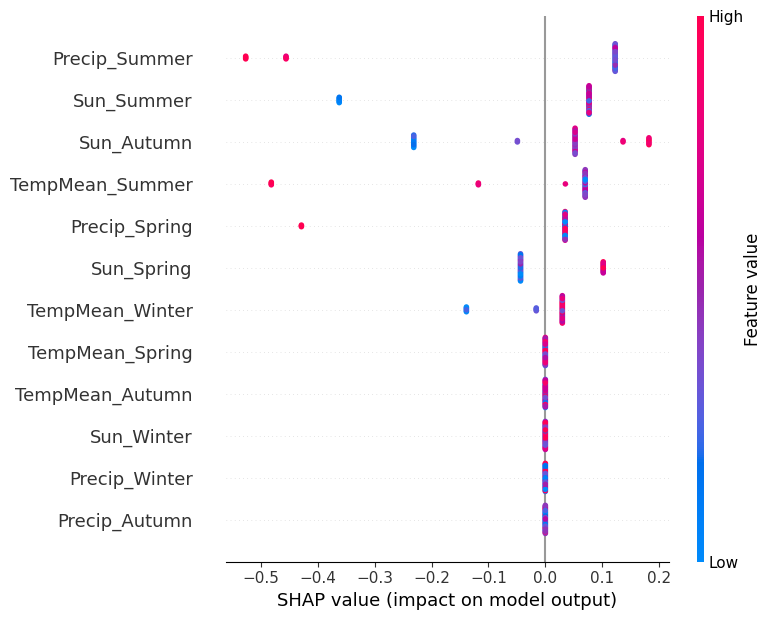


SpringBarley


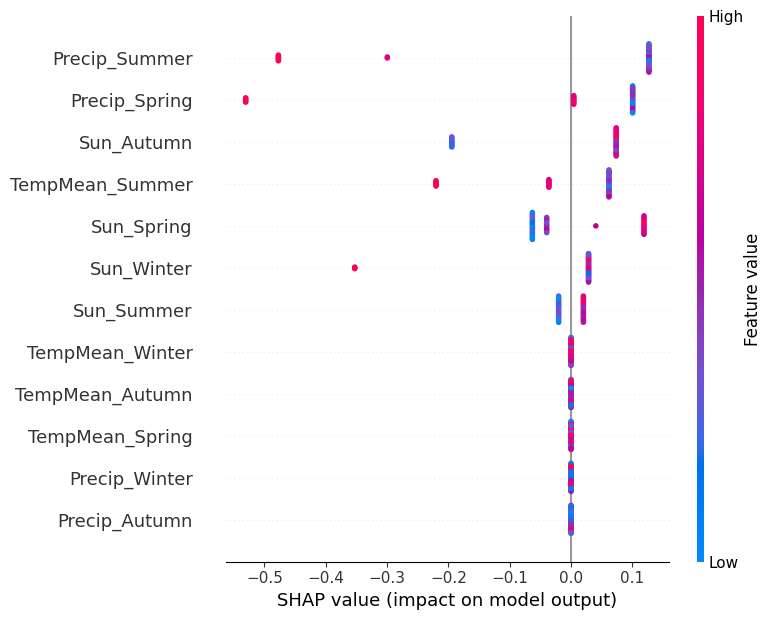


SpringOats


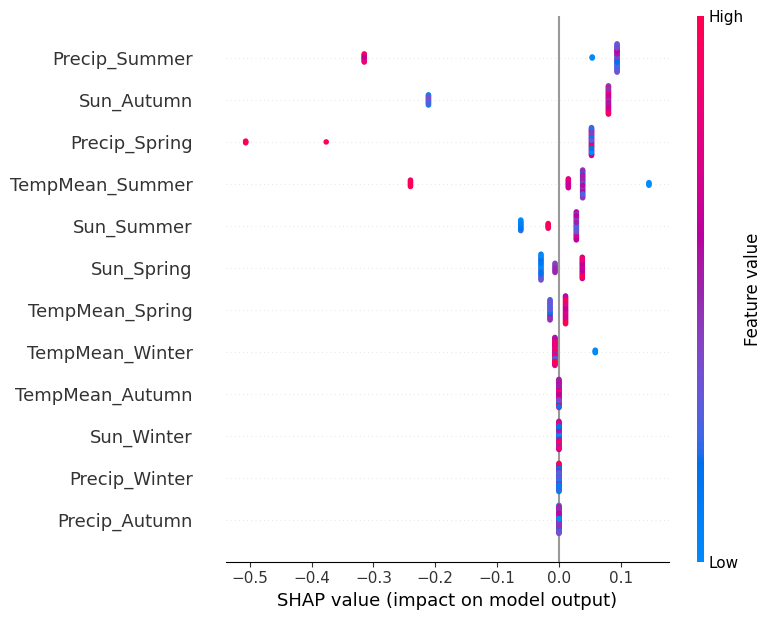


Potatoes


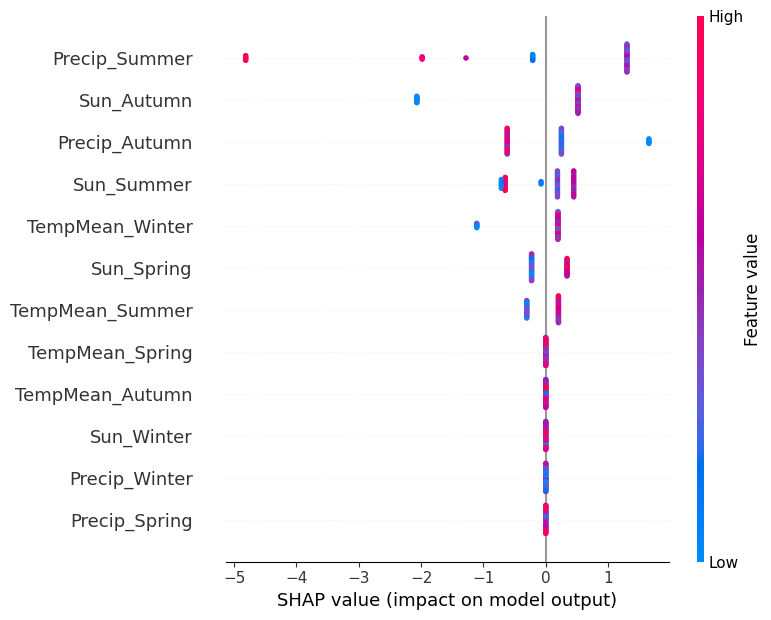

In [69]:
import shap
 
shap_crops = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
]
 
for csv, crop in shap_crops:
 
    yield_df = detrend_yield(pd.read_csv(csv)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    xgboost_model = xgb.XGBRegressor(random_state=42, **params_xgboost)
    xgboost_model.fit(X, y)
 
    explainer = shap.TreeExplainer(xgboost_model)
    shap_values = explainer.shap_values(X)
 
    print(f"\n{crop}")
    shap.summary_plot(shap_values, X)


SpringWheat (Random Forest)


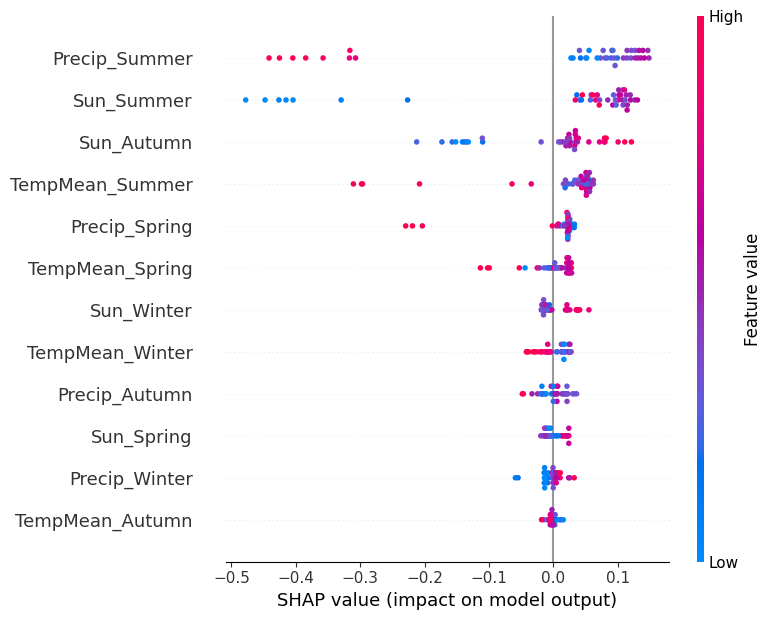


SpringBarley (Random Forest)


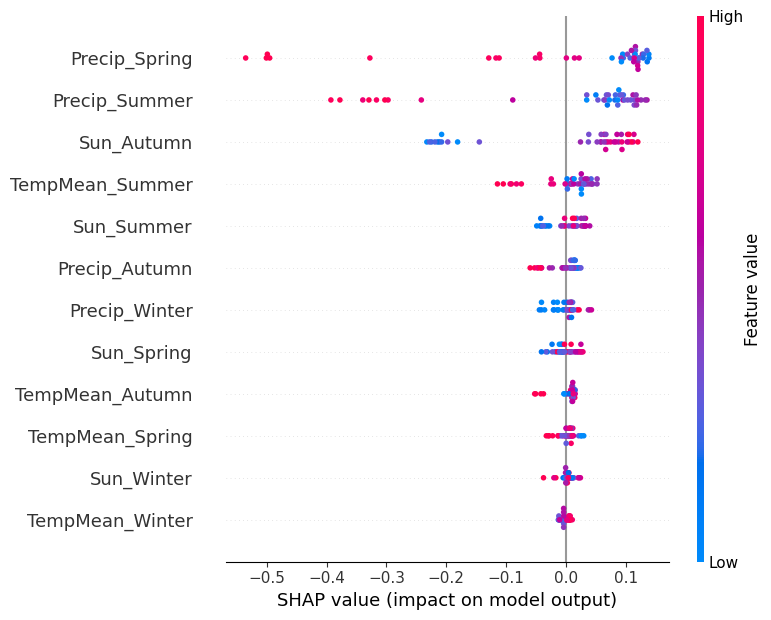


SpringOats (Random Forest)


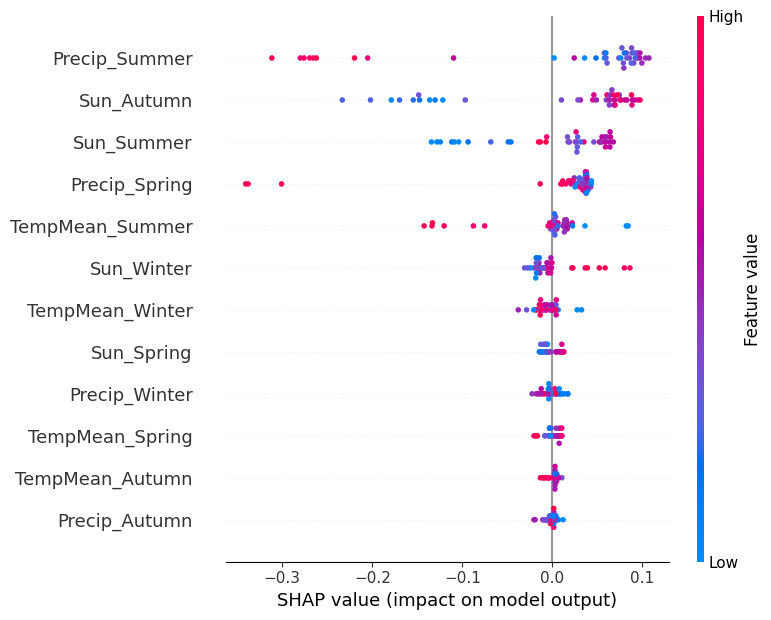


Potatoes (Random Forest)


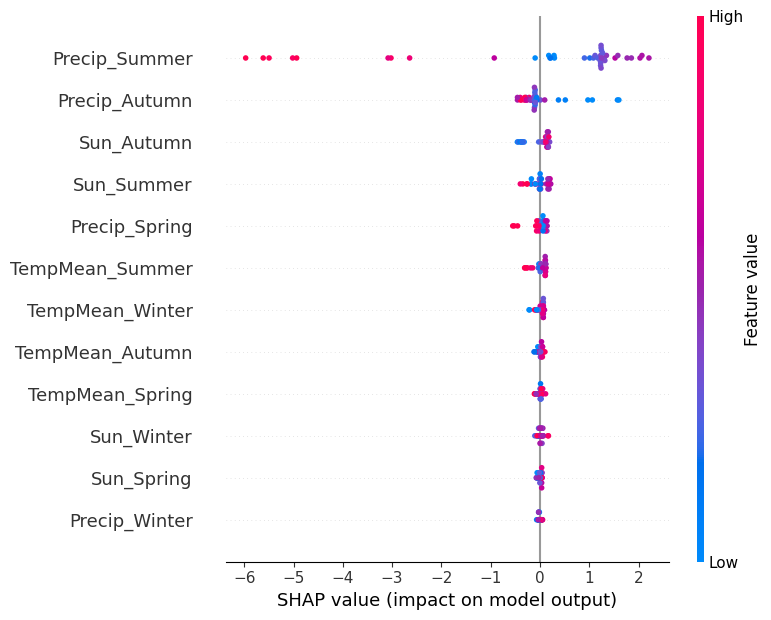

In [70]:
for csv, crop in shap_crops:
 
    yield_df = detrend_yield(pd.read_csv(csv)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    rf_model = RandomForestRegressor(random_state=42, **params_random_forest)
    rf_model.fit(X, y)
 
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X)
 
    print(f"\n{crop} (Random Forest)")
    shap.summary_plot(shap_values, X)

In [71]:
for csv_path, crop_name in shap_crops:

    explainer = shap.TreeExplainer(xgboost_model)
    shap_values = explainer.shap_values(X)

    print(f"\n{crop_name} XGBoost Mean SHAP per feature:")

    mean = np.abs(shap_values).mean(axis=0)
    sorted_pairs = sorted(zip(X.columns, mean), key=lambda p: p[1], reverse=True)

    for name, val in sorted_pairs[:5]:
        print(f"  {name:20s} {val:.4f}")

    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.close()


SpringWheat XGBoost Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322

SpringBarley XGBoost Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322

SpringOats XGBoost Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322

Potatoes XGBoost Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322


In [72]:

for csv_path, crop_name in shap_crops:

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X)

    print(f"\n{crop_name} Random Forest Mean SHAP per feature:")
    
    mean_absolute_error = np.abs(shap_values).mean(axis=0)
    sorted_pairs = sorted(zip(X.columns, mean), key=lambda p: p[1], reverse=True)

    for name, val in sorted_pairs[:5]:
        print(f"  {name:20s} {val:.4f}")

    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.close()


SpringWheat Random Forest Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322

SpringBarley Random Forest Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322

SpringOats Random Forest Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322

Potatoes Random Forest Mean SHAP per feature:
  Precip_Summer        1.6284
  Sun_Autumn           0.8275
  Precip_Autumn        0.5571
  Sun_Summer           0.4135
  TempMean_Winter      0.3322
